In [1]:
!pip install super-image rasterio matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 6.7 MB/s eta 0:00:00


https://huggingface.co/eugenesiow/han/resolve/main/pytorch_model_4x.pt
raw values -> min=1.0, max=20768.0, nodata=nan, valid_pixels=96.1%


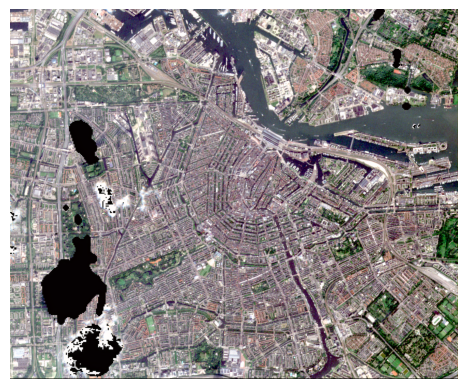

In [4]:
import numpy as np
import rasterio
import torch
import matplotlib.pyplot as plt
from super_image import HanModel

# Define the SR model. HAN is a 3-channel model, so use RGB bands below.
device = "cuda" if torch.cuda.is_available() else "cpu"
srmodel = HanModel.from_pretrained("eugenesiow/han", scale=4)
srmodel.to(device)
srmodel.eval()

# Set this to your Sentinel-2 RGB GeoTIFF (or a stacked multi-band raster).
S2_PATH = "/content/S2A_MSIL2A_20240817T105031_R051_T31UFU_20240817T143149_B02-B03-B04-B08_masked.tif"

# rasterio band indices are 1-based. The source file stores bands in the
# order B02, B03, B04, B08 (Blue, Green, Red, NIR), so pick the natural-color
# RGB bands in R, G, B order for the 3-channel HAN model.
BAND_INDICES = [3, 2, 1]  # R=B04, G=B03, B=B02

# Read the scene as [channels, height, width]. For Sentinel-2 L2A, values are
# commonly scaled by 10000; adjust REFLECTANCE_SCALE if your file is different.
# masked=True builds a mask from the raster's nodata value so masked/invalid
# pixels don't get scaled into range and blow the output out to solid white.
with rasterio.open(S2_PATH) as src:
    lr_masked = src.read(BAND_INDICES, masked=True)
    profile = src.profile.copy()

valid_mask = ~np.ma.getmaskarray(lr_masked)
lr = np.ma.filled(lr_masked, 0).astype(np.float32)

print(
    f"raw values -> min={lr[valid_mask].min() if valid_mask.any() else float('nan'):.1f}, "
    f"max={lr[valid_mask].max() if valid_mask.any() else float('nan'):.1f}, "
    f"nodata={profile.get('nodata')}, valid_pixels={valid_mask.mean():.1%}"
)

REFLECTANCE_SCALE = 10000.0
lr = lr / REFLECTANCE_SCALE

# Keep a raw (linear reflectance, unstretched) copy for scientific
# benchmarking tools such as opensr-test, whose metrics are only
# meaningful in linear reflectance space - not on the gamma/contrast-
# stretched visualization computed below.
lr_raw = lr.copy()
lr_raw[~valid_mask] = 0.0

# Sentinel-2 reflectance is linear-light data. HAN (like most photographic
# SR models) was trained on ordinary sRGB photos, which are gamma-encoded
# and already contrast-stretched. Feeding raw linear reflectance straight in
# is why the output looks flat, dark, and desaturated/grayish. Apply a
# per-band 2nd-98th percentile stretch (over valid pixels only) plus a
# ~sRGB gamma so the tonal range matches what the model expects.
GAMMA = 1 / 2.2
stretched = np.zeros_like(lr)
for b in range(lr.shape[0]):
    band, band_valid = lr[b], valid_mask[b]
    lo, hi = np.percentile(band[band_valid], [2, 98]) if band_valid.any() else (0.0, 1.0)
    stretched[b] = np.clip((band - lo) / (hi - lo + 1e-6), 0.0, 1.0)
lr = stretched ** GAMMA
lr[~valid_mask] = 0.0  # keep masked/nodata pixels black instead of stretched to gray
lr_img = torch.from_numpy(lr.astype(np.float32))
lr_raw_img = torch.from_numpy(lr_raw.astype(np.float32))

if lr_img.ndim != 3 or lr_img.shape[0] != 3:
    raise ValueError(f"Expected a 3-band raster, got shape {tuple(lr_img.shape)}")

# Run super-resolution. Output shape is [3, height * 4, width * 4].
# The raw-domain pass (sr_raw) is only needed if you plan to compute
# opensr-test style metrics later; skip it to save compute otherwise.
with torch.no_grad():
    sr_img = srmodel(lr_img.unsqueeze(0).to(device)).squeeze(0).cpu().clamp(0, 1)
    sr_raw = srmodel(lr_raw_img.unsqueeze(0).to(device)).squeeze(0).cpu().clamp(0, 1)

# Save the output as a float32 GeoTIFF, preserving the source CRS and transform.
# The transform is scaled because the pixel size is 4x finer after SR.
output_profile = profile.copy()
# Drop the source file's block-size settings: they were sized for the
# original (4x smaller) raster and, if the source is strip-organized
# (tiled=False) while still reporting a blockxsize, GDAL raises
# "BLOCKXSIZE can only be used with TILED=YES" on write. Explicitly tile
# the output instead, which is also more efficient for the larger SR file.
output_profile.pop("blockxsize", None)
output_profile.pop("blockysize", None)
output_profile.update(
    driver="GTiff",
    count=3,
    dtype="float32",
    height=sr_img.shape[1],
    width=sr_img.shape[2],
    transform=profile["transform"] * rasterio.Affine.scale(1 / 4, 1 / 4),
    nodata=None,
    tiled=True,
    blockxsize=256,
    blockysize=256,
)

with rasterio.open("sentinel2_han_x4.tif", "w", **output_profile) as dst:
    dst.write(sr_img.numpy())

# Display the super-resolved RGB image.
plt.imshow(sr_img.permute(1, 2, 0).numpy())
plt.axis("off")
plt.show()

# Metrics require a matching HR reference raster, registered to this input
# scene. See the next cell - it uses lr_raw/sr_raw (linear reflectance,
# not the stretched image above) with opensr-test.

In [7]:
!pip install git+https://github.com/ESAOpenSR/opensr-test

  Cloning https://github.com/ESAOpenSR/opensr-test to /tmp/pip-req-build-toaiftwu
  Running command git clone --filter=blob:none --quiet https://github.com/ESAOpenSR/opensr-test /tmp/pip-req-build-toaiftwu
  Resolved https://github.com/ESAOpenSR/opensr-test to commit b42b1cba8a04b32341044f1f29474e5448499158
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


(<Figure size 640x480 with 1 Axes>,
 <TernaryAxes: tlabel='Im', llabel='Om', rlabel='Ha'>)

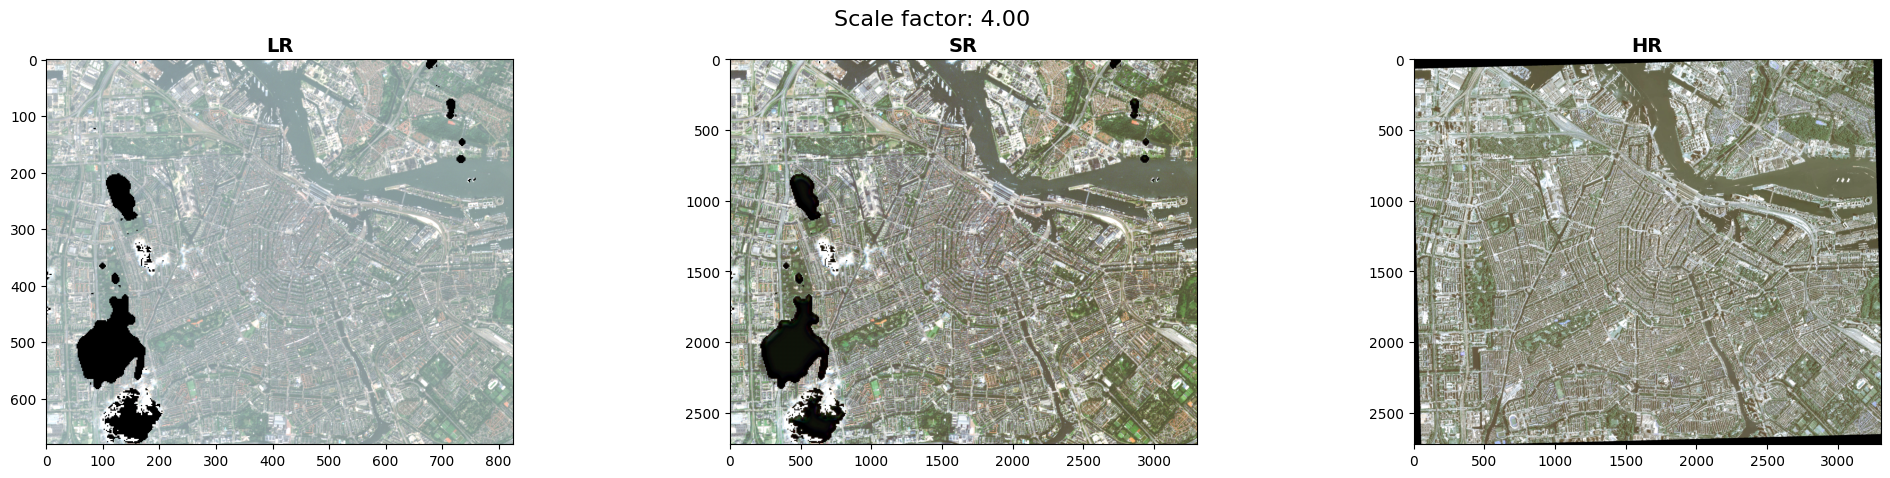

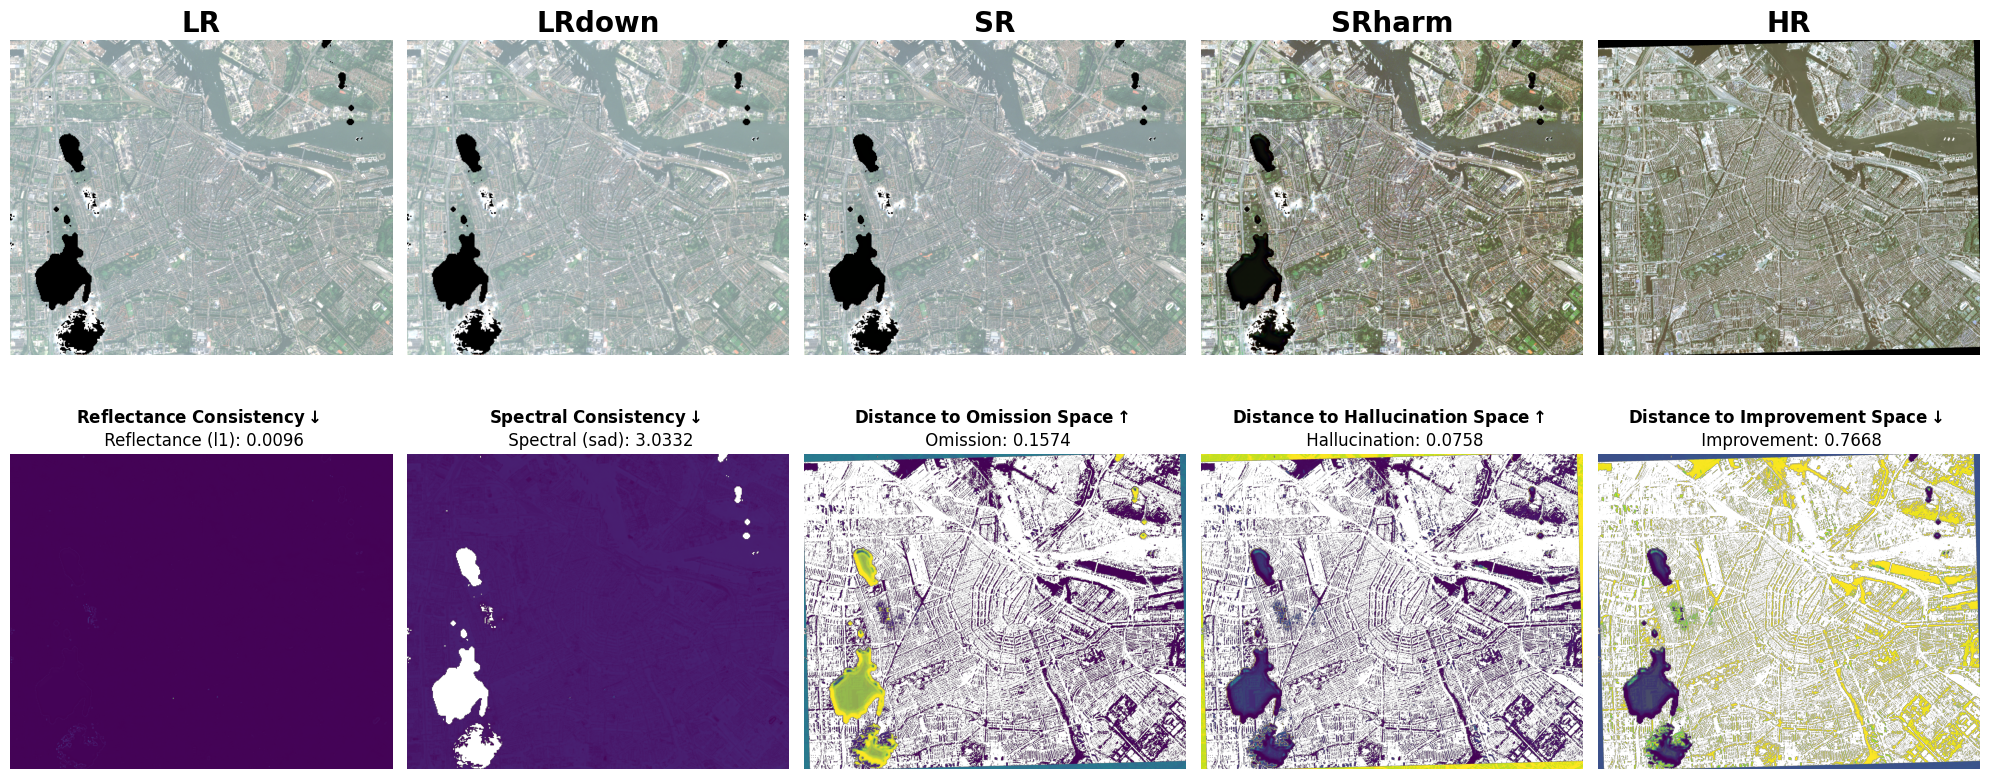

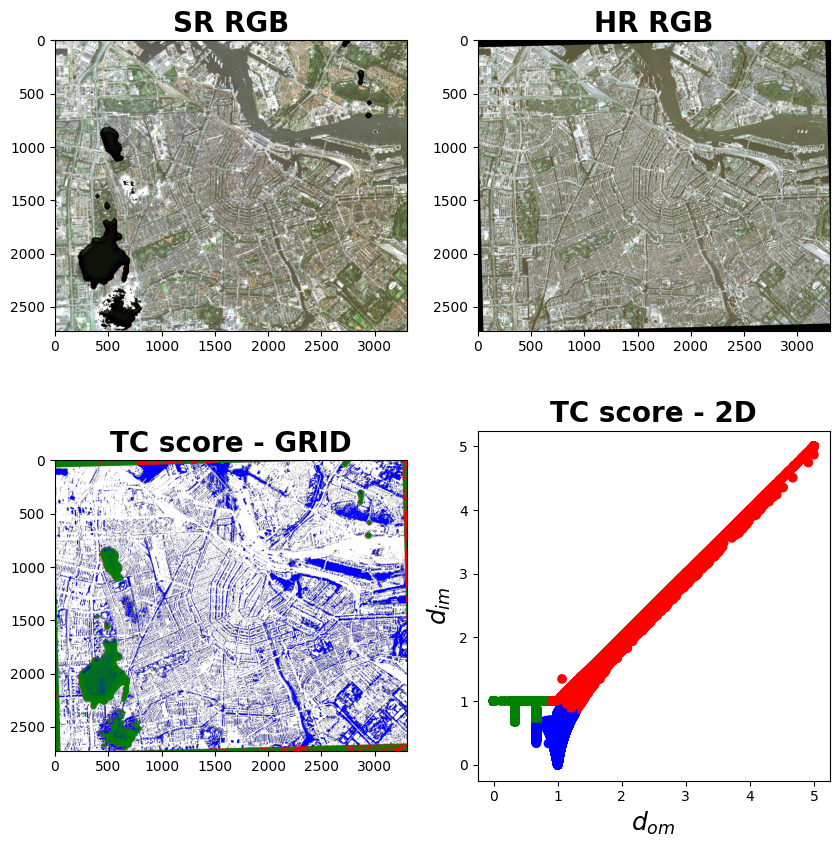

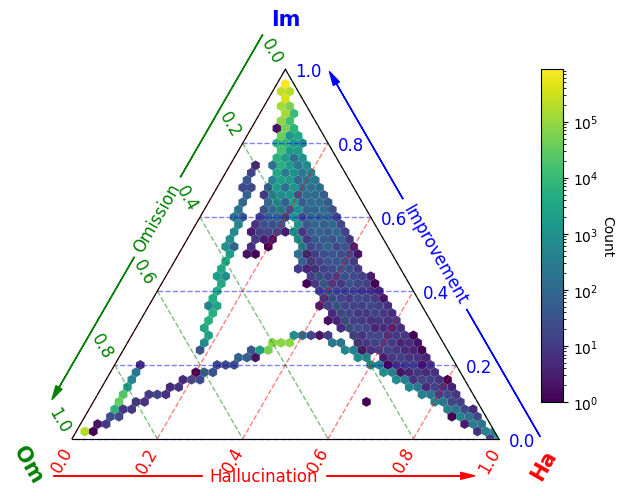

In [9]:
import os
import opensr_test
from rasterio.warp import reproject, Resampling

# `metrics` comes from the opensr-test package - a benchmark suite built
# specifically for satellite-imagery SR (github.com/ESAOpenSR/opensr-test).
# Its metrics only make sense in *linear reflectance* space, so this cell
# uses lr_raw/sr_raw from the previous cell, not the gamma-stretched
# lr_img/sr_img used for the display image.
#
# It also needs a real, matching HIGH-RESOLUTION reference of this exact
# Amsterdam footprint (e.g. co-registered aerial orthophotography) - there
# is no way to synthesize that from the Sentinel-2 scene alone. Point
# HR_PATH at one if you have it; otherwise this falls back to a quick demo
# using one of opensr-test's built-in pre-matched benchmark datasets so you
# can still see how the metrics/plots work.
HR_PATH = "/content/amsterdam_urban_orthophoto_25cm.tif"  # <-- set to your own HR reference GeoTIFF, if you have one
SR_SCALE = 4  # must match HanModel.from_pretrained(..., scale=SR_SCALE)

config = opensr_test.Config()
metrics = opensr_test.Metrics(config=config)

if HR_PATH and os.path.exists(HR_PATH):
    # opensr_test.Metrics.compute requires hr.width / lr.width to be an
    # exact integer. Reading the HR file at its own native resolution/extent
    # almost never satisfies that, so reproject/resample it onto a grid
    # that's forced to be exactly SR_SCALE x the LR raster's pixel grid -
    # same CRS, same footprint, same integer ratio - rather than reading it
    # as-is.
    lr_height, lr_width = lr_raw_img.shape[-2:]
    target_transform = profile["transform"] * rasterio.Affine.scale(1 / SR_SCALE, 1 / SR_SCALE)
    target_height, target_width = lr_height * SR_SCALE, lr_width * SR_SCALE

    with rasterio.open(HR_PATH) as hr_src:
        hr_raw = np.full((len(BAND_INDICES), target_height, target_width), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(hr_src, BAND_INDICES),
            destination=hr_raw,
            src_transform=hr_src.transform,
            src_crs=hr_src.crs,
            src_nodata=hr_src.nodata,
            dst_transform=target_transform,
            dst_crs=profile["crs"],
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )

    hr_valid = ~np.isnan(hr_raw)
    hr_raw = np.nan_to_num(hr_raw, nan=0.0) / REFLECTANCE_SCALE
    hr_raw[~hr_valid] = 0.0
    hr_img = torch.from_numpy(hr_raw.astype(np.float32))

    metrics.compute(lr=lr_raw_img, sr=sr_raw, hr=hr_img)
else:
    print(f"No HR_PATH set (or file not found) - running the 'spain_urban' demo dataset instead.\n")
    dataset = opensr_test.load("spain_urban")
    lr_demo, hr_demo = dataset["L2A"], dataset["HRharm"]
    idx = 0
    lr_bench = torch.from_numpy(lr_demo[idx, 0:3]) / REFLECTANCE_SCALE
    hr_bench = torch.from_numpy(hr_demo[idx, 0:3]) / REFLECTANCE_SCALE
    with torch.no_grad():
        sr_bench = srmodel(lr_bench[None].to(device)).squeeze().cpu().clamp(0, 1)

    metrics.compute(lr=lr_bench, sr=sr_bench, hr=hr_bench)

metrics.plot_triplets()
metrics.plot_summary()
metrics.plot_tc()
metrics.plot_ternary()